In [1]:
# Drive Mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
cd /content/drive/MyDrive/sejong/detection

/content/drive/MyDrive/sejong/detection


In [3]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.7 MB/s eta 0:00:00


# 바운딩 박스 그리기

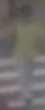

In [3]:
import cv2
from google.colab.patches import cv2_imshow

def draw_bounding_box(image_path, bbox):
    img = cv2.imread(image_path)
    height, width, _ = img.shape
    x_center, y_center, box_width, box_height = bbox

    x1 = int((x_center - box_width / 2) * width)
    y1 = int((y_center - box_height / 2) * height)
    x2 = int((x_center + box_width / 2) * width)
    y2 = int((y_center + box_height / 2) * height)

    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2_imshow(img)


def crop_bounding_box(image_path, bbox):
    img = cv2.imread(image_path)
    height, width, _ = img.shape
    x_center, y_center, box_width, box_height = bbox

    # 좌표 변환 (YOLO 형식 → 픽셀 좌표)
    x1 = int((x_center - box_width / 2) * width)
    y1 = int((y_center - box_height / 2) * height)
    x2 = int((x_center + box_width / 2) * width)
    y2 = int((y_center + box_height / 2) * height)

    # 이미지 크롭 (y는 세로축, x는 가로축)
    cropped_img = img[y1:y2, x1:x2]

    cv2_imshow(cropped_img)


image_path = './data/detection/images/1245.jpg'
bbox = [0.855469, 0.564815, 0.023438, 0.101852]
# draw_bounding_box(image_path, bbox)

crop_bounding_box(image_path, bbox)

In [44]:
filename = './data/detection/labels/1450.txt'
f = open(filename, 'r')
lines = f.readlines()
print(lines)
print('-' * 10)

for line in lines:
    print(line)

# with open('./data/detection/labels/1450.txt', 'r') as f:
#     content = f.read()
#     print(content)


['1 0.050260 0.695833 0.031771 0.121296\n']
----------
1 0.050260 0.695833 0.031771 0.121296



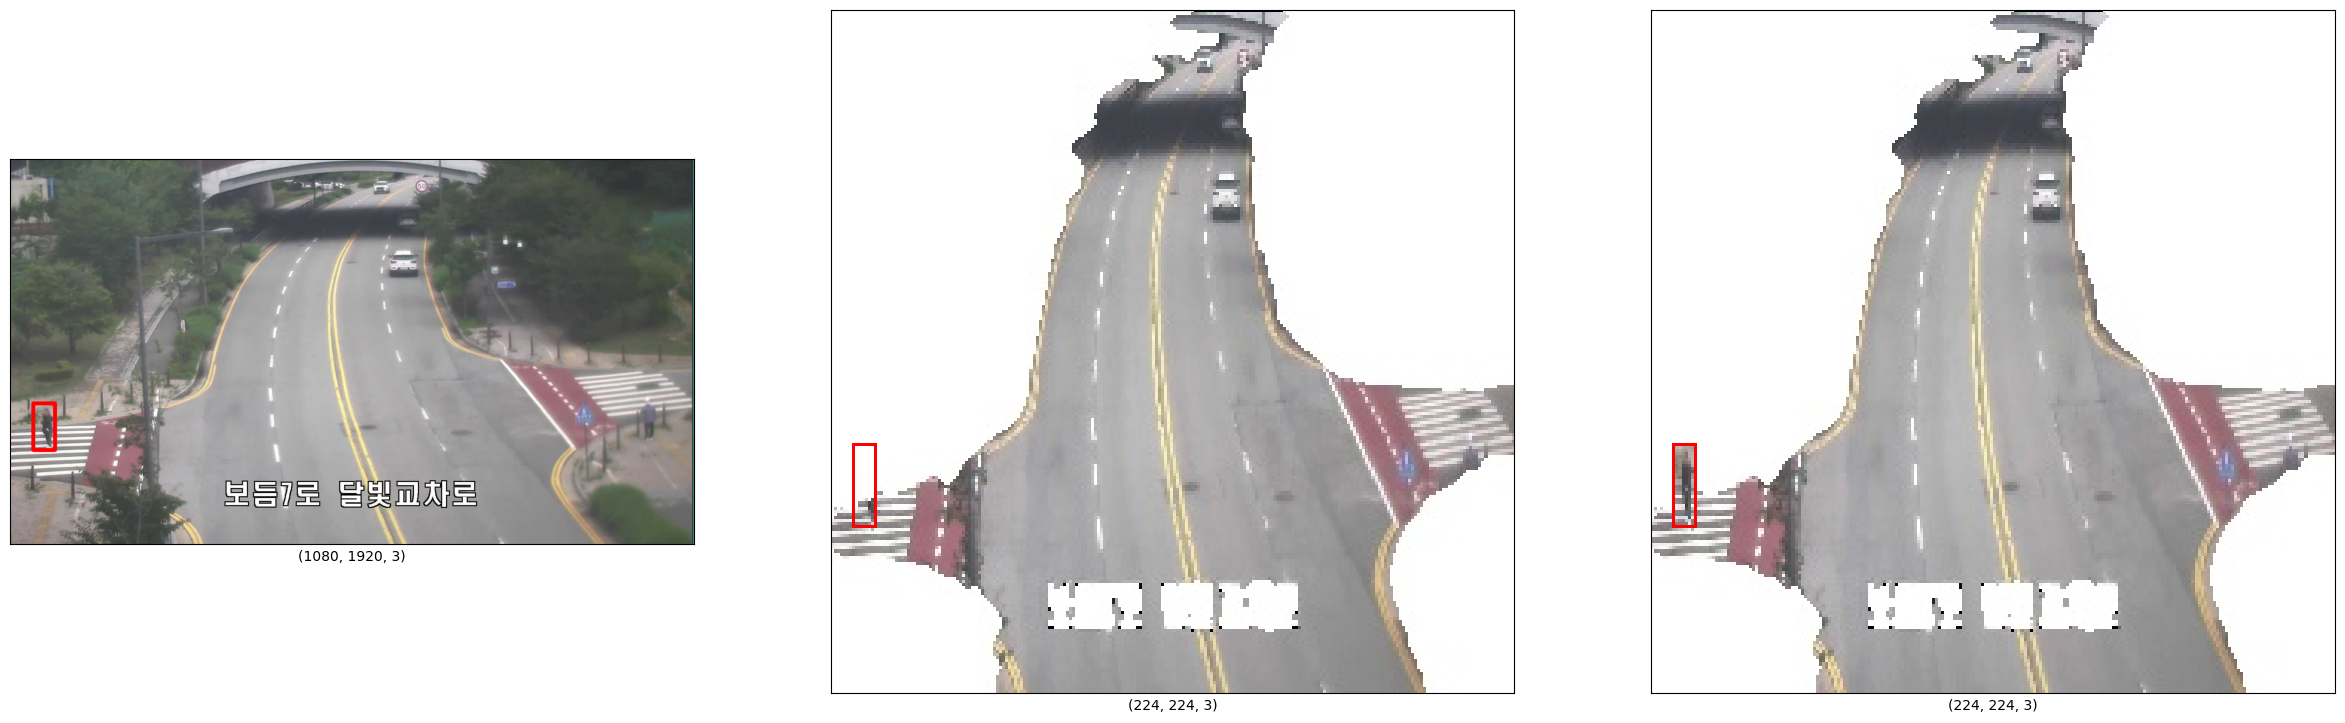

In [13]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

def crop_from_A_and_paste_to_B(imageA_path, imageB_path, bbox):
    # 이미지 읽기
    imgA = cv2.imread(imageA_path)
    imgB = cv2.imread(imageB_path)
    img = imgB.copy()

    heightA, widthA, _ = imgA.shape  # (1080, 1920, 3)
    heightB, widthB, _ = imgB.shape  # (224, 224, 3)

    # YOLO bbox (x_center, y_center, w, h)
    x_center, y_center, box_width, box_height = bbox

    # A에서 픽셀 단위 bbox 구하기
    x1_A = int((x_center - box_width / 2) * widthA)
    y1_A = int((y_center - box_height / 2) * heightA)
    x2_A = int((x_center + box_width / 2) * widthA)
    y2_A = int((y_center + box_height / 2) * heightA)

    # Step 1: 이미지 A에서 crop
    cropped = imgA[y1_A:y2_A, x1_A:x2_A]

    # Step 2: A 좌표를 B 크기에 맞게 변환
    x1_B = int(x1_A / widthA * widthB)
    y1_B = int(y1_A / heightA * heightB)
    x2_B = int(x2_A / widthA * widthB)
    y2_B = int(y2_A / heightA * heightB)

    # Step 3: crop 이미지 resize → B 좌표 크기에 맞게
    cropped_resized = cv2.resize(cropped, (x2_B - x1_B, y2_B - y1_B))

    # Step 4: B에 붙여넣기
    imgB[y1_B:y2_B, x1_B:x2_B] = cropped_resized

    # cv2_imshow(imgB)

    plt.figure(figsize=(30, 10))

    plt.subplot(1,3,1)
    plt.xticks([])
    plt.yticks([])
    cv2.rectangle(imgA, (x1_A, y1_A), (x2_A, y2_A), (0, 0, 255), 10)
    plt.imshow(imgA[:,:,::-1])

    plt.subplot(1,3,2)
    plt.xticks([])
    plt.yticks([])
    cv2.rectangle(img, (x1_B, y1_B), (x2_B, y2_B), (0, 0, 255), 1)
    plt.imshow(img[:,:,::-1])

    plt.subplot(1,3,3)
    plt.xticks([])
    plt.yticks([])
    cv2.rectangle(imgB, (x1_B, y1_B), (x2_B, y2_B), (0, 0, 255), 1)
    plt.imshow(imgB[:,:,::-1])

# 예시 실행
imageA_path = './data/detection/images/1450.jpg'   # 큰 원본 이미지
imageB_path = './data/segmentation_images/images/1450.jpg'  # 작은 대상 이미지
bbox = [0.050260, 0.695833, 0.031771, 0.121296]

crop_from_A_and_paste_to_B(imageA_path, imageB_path, bbox)


# Custom yaml 파일

In [3]:
import yaml
with open('./custom.yaml', 'r') as f:
    yaml_data = yaml.safe_load(f)
    display(yaml_data)

{'names': ['jaywalker', 'pedestrian'],
 'nc': 2,
 'test': '/content/drive/MyDrive/sejong/detection/data/only_seg/test',
 'train': '/content/drive/MyDrive/sejong/detection/data/only_seg/train',
 'val': '/content/drive/MyDrive/sejong/detection/data/only_seg/val'}

# Modeling

In [4]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.1/235.7 GB disk)


In [6]:
pwd

'/content/drive/MyDrive/sejong/detection'

In [9]:
from ultralytics import YOLO
model = YOLO('yolov8m.pt')

In [10]:
model.train(data='./custom.yaml', cfg='./cfg.yaml')

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in in the future.
WARNING ⚠️ 'save_hybrid' is deprecated and will be removed in in the future.
Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=./cfg.yaml, classes=None, close_mosaic=10, cls=0.5, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./custom.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=3, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8, nbs

Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytics

 19                  -1  1   1327872  ultralytics.nn.modules.conv.Conv             [384, 384, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  2   4207104  ultralytics.nn.modules.block.C2f             [960, 576, 2]                 
 22        [15, 18, 21]  1   3776854  ultralytics.nn.modules.head.Detect           [2, [192, 384, 576]]          
Model summary: 169 layers, 25,857,478 parameters, 25,857,462 gradients, 79.1 GFLOPs

Transferred 469/475 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.3±0.1 MB/s, size: 138.1 KB)


train: Scanning /content/drive/MyDrive/sejong/detection/data/only_seg/train/labels... 2350 images, 278 backgrounds, 2 corrupt: 100%|██████████| 2628/2628 [21:05<00:00,  2.08it/s]

...

                   all        232        504      0.778     0.0245      0.402      0.167
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 3, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



8 epochs completed in 0.224 hours.
Optimizer stripped from detection/yolov8/weights/last.pt, 52.0MB
Optimizer stripped from detection/yolov8/weights/best.pt, 52.0MB

Validating detection/yolov8/weights/best.pt...
Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:05<00:00,  1.35it/s]


                   all        232        504      0.929     0.0313      0.481      0.266
             jaywalker        116        233      0.857     0.0515      0.456      0.229
            pedestrian        138        271          1     0.0111      0.506      0.303
Speed: 0.4ms preprocess, 19.3ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to detection/yolov8


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79d9afbb6e10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [11]:
metrics = model.val()  # 검증 후 성능 지표

Ultralytics 8.3.185 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.7 ms, read: 67.9±30.1 MB/s, size: 146.3 KB)


val: Scanning /content/drive/MyDrive/sejong/detection/data/only_seg/val/labels.cache... 232 images, 0 backgrounds, 0 corrupt: 100%|██████████| 232/232 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 15/15 [00:08<00:00,  1.78it/s]


                   all        232        504      0.929     0.0313       0.48      0.257
             jaywalker        116        233      0.857     0.0515      0.455      0.228
            pedestrian        138        271          1     0.0111      0.506      0.287
Speed: 2.7ms preprocess, 28.3ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to detection/yolov8


In [12]:
print(f"YOLOv8m mAP.50: {metrics.box.map50:.4f}")

YOLOv8m mAP.50: 0.4801


In [ ]:
#!/usr/bin/env python
# coding: utf-8

# In[ ]:


import argparse
import glob
import os
import time
from PIL import Image
from ultralytics import YOLO

def run_inference(model_path,test_dir,result_dir):
    model_path = args.model_path
    test_dir = args.test_dir
    result_dir = args.result_dir

    # 모델 정의
    model = YOLO(model_path)

    # 모델 예측 결과 저장
    results = model.predict(source=test_dir, project=result_dir, show_conf=False, save_txt=True, save=True)

    time.sleep(2)

    images = sorted(glob.glob(f'./{result_dir}/predict/*.jpg'),key=lambda x: os.path.splitext(x)[0])
    labels = sorted(glob.glob(f'./{result_dir}/predict/labels/*.txt'),key=lambda x: os.path.splitext(x)[0])

    # 이미지와 라벨을 순서대로 매칭하여 변환
    for image_path, label_path in zip(images, labels):
        image_path = image_path.replace('\\','/')
        label_path = label_path.replace('\\','/')
        # 이미지 크기 가져오기
        w, h = Image.open(image_path).size

        # 변환된 좌표를 저장할 리스트
        voc_labels = []

        # 라벨 파일 읽기
        with open(label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                # YOLO 형식 데이터 파싱
                label, x_center, y_center, box_width, box_height = line.split()

                # VOC 형식 좌표 계산
                x_min = round(w * max(float(x_center) - float(box_width) / 2, 0),5)
                x_max = round(w * min(float(x_center) + float(box_width) / 2, 1),5)
                y_min = round(h * max(float(y_center) - float(box_height) / 2, 0),5)
                y_max = round(h * min(float(y_center) + float(box_height) / 2, 1),5)

                # 변환된 좌표를 리스트에 추가
                voc_labels.append(f"{label} {x_min:.6f} {y_min:.6f} {x_max:.6f} {y_max:.6f}")

        with open(label_path, 'w') as f:
            f.write("\n".join(voc_labels))


model_path = './yolov8/weights/best.pt'
test_dir = './평가용데이터셋/images/'
result_dir = '추론결과'
run_inference(model_path,test_dir,result_dir)


In [32]:
import shutil
import random
import numpy as np

In [29]:
original_img = sorted(glob.glob('./data/detection/images/*.jpg'),key=lambda x: int(x.split('/')[-1].split('.')[0]))
original_label = sorted(glob.glob('./data/detection/labels/*.txt'),key=lambda x: int(x.split('/')[-1].split('.')[0]))

In [35]:
split_ratio=[9,0.8,0.2]
modes = ['train', 'val', 'test']
det_data_dir = './data/detection'
# det_data_dir = './data/new_data'

for data_dir, img_ext, label_ext in [(det_data_dir, '.jpg', '.txt')]:
    # img_list = sorted(glob.glob(f'{data_dir}/images/*{img_ext}'), key=lambda x: os.path.splitext(x)[0])
    jaywalker = []
    pedestrian = []
    sidewalk = []

    label_path = glob.glob(f'{det_data_dir}/labels/*{label_ext}')
    # label_path = sorted(glob.glob('./ori_seg/train/labels/*.txt'),key=lambda x: int(x.split('/')[-1].split('.')[0]))[:831]
    for label in label_path:
        with open(label, 'r') as f:
            lines = f.readlines()
            jaywalker_coords = []  # jaywalker의 좌표를 저장할 리스트
            pedestrian_coords = []  # pedestrian의 좌표를 저장할 리스트
            for line in lines:
                if line.strip() and line[0] == '0':  # 클래스 ID가 '0'인 경우
                    jaywalker_coords.append(line.strip())  # 해당 라인을 좌표 리스트에 추가
                elif line.strip() and line[0] == '1':  # 클래스 ID가 '1'인 경우
                    pedestrian_coords.append(line.strip())  # 해당 라인을 좌표 리스트에 추가
            # 파일에 '0'과 '1'이 모두 있는 경우 jaywalker에 추가
            if jaywalker_coords and pedestrian_coords:
                jaywalker.append([label.split('/')[-1], jaywalker_coords + pedestrian_coords])
            # 파일에 '0'만 있는 경우에도 jaywalker에 추가
            elif jaywalker_coords:
                jaywalker.append([label.split('/')[-1], jaywalker_coords])
            # 파일에 '1'만 있는 경우 pedestrian에 추가
            elif pedestrian_coords:
                pedestrian.append([label.split('/')[-1], pedestrian_coords])

    random.seed(100)
    random.shuffle(jaywalker)
    random.shuffle(pedestrian)
    # jaywalker = sorted(jaywalker, key=lambda x: x[0])
    # pedestrian = sorted(pedestrian, key=lambda x: x[0])
    # Calculate the split sizes
    data_num = len(label_path)
    val_num = int(np.floor(data_num * (split_ratio[1] / 10)))
    test_num = int(np.floor(data_num * (split_ratio[2] / 10)))
    train_num = data_num - (val_num + test_num) # Adjust to avoid mismatch

    # Move to Directory
    # Test: jaywalker:30, pedestrian:30
    for i in range(test_num//2):
      shutil.copy(f'{det_data_dir}/labels/{jaywalker[i][0]}',f'./data/only_seg/{modes[2]}/labels/')
      shutil.copy(f'{det_data_dir}/labels/{pedestrian[i][0]}',f'./data/only_seg/{modes[2]}/labels/')
      shutil.copy(f"{det_data_dir}/images/{jaywalker[i][0].replace('.txt','.jpg')}",f"./data/only_seg/{modes[2]}/images/")
      shutil.copy(f"{det_data_dir}/images/{pedestrian[i][0].replace('.txt','.jpg')}",f"./data/only_seg/{modes[2]}/images/")

    ## Val: jaywalker:30, pedestrian:30
    for i in range(test_num//2,(test_num//2) + (val_num//2)):
      shutil.copy(f'{det_data_dir}/labels/{jaywalker[i][0]}',f'./data/only_seg/{modes[1]}/labels/')
      shutil.copy(f'{det_data_dir}/labels/{pedestrian[i][0]}',f'./data/only_seg/{modes[1]}/labels/')
      shutil.copy(f"{det_data_dir}/images/{jaywalker[i][0].replace('.txt','.jpg')}",f"./data/only_seg/{modes[1]}/images/")
      shutil.copy(f"{det_data_dir}/images/{pedestrian[i][0].replace('.txt','.jpg')}",f"./data/only_seg/{modes[1]}/images/")

    ## Train: jaywalker:11, pedestrian:423
    for i in range((test_num//2) + (val_num//2),len(jaywalker)):
      shutil.copy(f'{det_data_dir}/labels/{jaywalker[i][0]}',f'./data/only_seg/{modes[0]}/labels/')
      shutil.copy(f"{det_data_dir}/images/{jaywalker[i][0].replace('.txt','.jpg')}",f"./data/only_seg/{modes[0]}/images/")
    for i in range((test_num//2) + (val_num//2),len(pedestrian)):
      shutil.copy(f'{det_data_dir}/labels/{pedestrian[i][0]}',f'./data/only_seg/{modes[0]}/labels/')
      shutil.copy(f"{det_data_dir}/images/{pedestrian[i][0].replace('.txt','.jpg')}",f"./data/only_seg/{modes[0]}/images/")

    print('val',val_num)
    print('test',test_num)
    print('train',train_num)

print('jaywalker',len(jaywalker))
print('pedestrian',len(pedestrian))
print(len(glob.glob('./data/detection/images/*.jpg')),len(glob.glob('./data/detection/labels/*.txt')))

val 233
test 58
train 2627
jaywalker 891
pedestrian 2027
2918 2918


In [36]:
modes = ['train','val','test']
for mode in modes:
  print(mode,':',len(glob.glob(f'./data/only_seg/{mode}/images/*.jpg')),len(glob.glob(f'./data/only_seg/{mode}/labels/*.txt')))

train : 2628 2628
val : 232 232
test : 58 58


In [51]:
sorted(glob.glob('./data/only_seg/train/images/*.jpg'),key=lambda x: int(x.split('/')[-1].split('.')[0]))[-1]

'./data/only_seg/train/images/5545.jpg'

In [50]:
path = sorted(glob.glob('./data/segmentation_images/images/*.jpg'),key=lambda x: int(x.split('/')[-1].split('.')[0]))

for i,p in enumerate(path):
  shutil.copy(p,f'./data/only_seg/train/images/{i+2628}.jpg')